# Draftly corpus EDA

Exploratory look at every dataset Draftly's retrieval side currently holds:
the statutory sources, the canonical processed store, the case-law corpus, and
the case-law rule-extraction output.

It also answers three concrete questions about case law:

- what a **reported** case is versus an **unreported** one,
- a **headnote we can extract** deterministically,
- a **headnote we cannot** cleanly extract, and a case with **no headnote at all**.

Every number is read live from disk. Nothing is hard-coded, so re-running after a
data rebuild reflects the current state. All generated case/statute links and all
extracted rules are `status=unverified` until a lawyer reviews them.

## 0. Setup

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Find the repo root by walking up until data/processed appears.
ROOT = Path.cwd()
while not (ROOT / "data" / "processed").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
assert (ROOT / "data" / "processed").exists(), "Could not locate repo root"

PROCESSED = ROOT / "data" / "processed"
MANIFESTS = ROOT / "data" / "legal-sources" / "manifests"
EXTRACT = ROOT / "scripts" / "case-law-information-extraction"
OUTPUT = EXTRACT / "output"

# Muted, consistent palette so every chart reads as one set.
PAL = ["#2F6F5E", "#C08A2D", "#7A8B99", "#8A5510", "#4E6E5D", "#B0663A", "#3E5C6E"]
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

def barh(labels, values, title, xlabel="count", color=PAL[0]):
    fig, ax = plt.subplots(figsize=(7, 0.5 * len(labels) + 1.2))
    ax.barh(range(len(labels)), values, color=color)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel(xlabel)
    ax.set_title(title, loc="left", fontweight="bold")
    for i, v in enumerate(values):
        ax.text(v, i, f" {v:,}", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()

print("repo root:", ROOT)

repo root: D:\projects\Draftly-Project\draftly-research


## 1. The corpus at a glance

`store-summary.json` is the headline count of the canonical processed store, the
one directory retrieval reads from. `documents.csv` records one row per
normalized document with full provenance; `cases.jsonl` is one row per case.

In [2]:
summary = json.loads((PROCESSED / "store-summary.json").read_text(encoding="utf-8"))
print("=== store-summary.json ===")
for k, v in summary.items():
    print(f"{k:28s} {v}")

docs = pd.read_csv(PROCESSED / "documents.csv", low_memory=False)
cases = pd.read_json(PROCESSED / "cases.jsonl", lines=True)
print("\ndocuments.csv:", docs.shape, "| columns:", list(docs.columns))
print("cases.jsonl  :", cases.shape, "| columns:", list(cases.columns))

=== store-summary.json ===
generated_at_utc             2026-07-16T13:40:20.063000+00:00
documents                    9295
legal_source_documents       85
commonlii_judgments          3703
official_court_judgments     5474
internet_archive_volumes     33
case_records                 9177
missing_or_low_text          0



documents.csv: (9295, 21) | columns: ['doc_id', 'source_id', 'source_record_id', 'kind', 'source', 'title', 'court', 'year', 'citation', 'origin_url', 'local_pdf', 'raw_text_path', 'text_path', 'converter', 'converter_version', 'status', 'retrieved_date', 'retrieved_date_source', 'chars', 'sha256', 'quality_flags']
cases.jsonl  : (9177, 13) | columns: ['case_id', 'doc_id', 'source', 'source_record_id', 'court', 'year', 'citation', 'title', 'url', 'text_path', 'hits', 'conveyancing_match', 'status']


documents by kind 
 kind
case-law             9177
statute                57
case-law-volume        33
amendment              18
gazette                 7
institution-guide       3
Name: count, dtype: int64 

documents by source
 source
official-courts     5474
commonlii           3703
source-registry       85
internet-archive      33
Name: count, dtype: int64


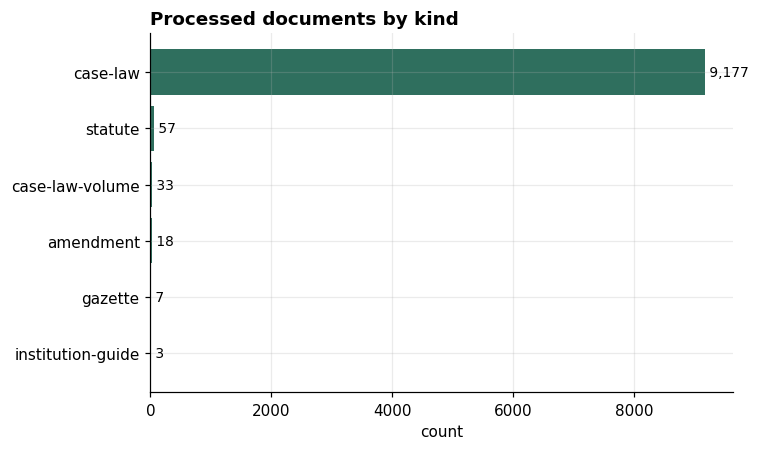

In [3]:
# What kinds of documents make up the store, and where they came from.
kind_col = "kind" if "kind" in docs.columns else "source"
by_kind = docs[kind_col].value_counts()
print("documents by", kind_col, "\n", by_kind, "\n")
print("documents by source\n", docs["source"].value_counts())
barh(by_kind.index.tolist(), by_kind.values.tolist(),
     f"Processed documents by {kind_col}")

## 2. The law itself (statutory sources)

Separate from the judgments, `source-registry.csv` is the curated catalogue of
the primary law: statutes, amendments, gazettes and reference guides. This is the
authority a rule or answer must cite.

source-registry.csv: (90, 13)

by source_type
 source_type
statute              57
amendment            18
gazette               7
institution-guide     3
case-law              3
textbook              1
curriculum-term       1
Name: count, dtype: int64

by status
 status
downloaded               83
indexed-reference         3
indexed-html              1
needs-official-source     1
bibliographic-only        1
needs-manual-review       1
Name: count, dtype: int64

curriculum topics: 20 | topic<->source edges: 174


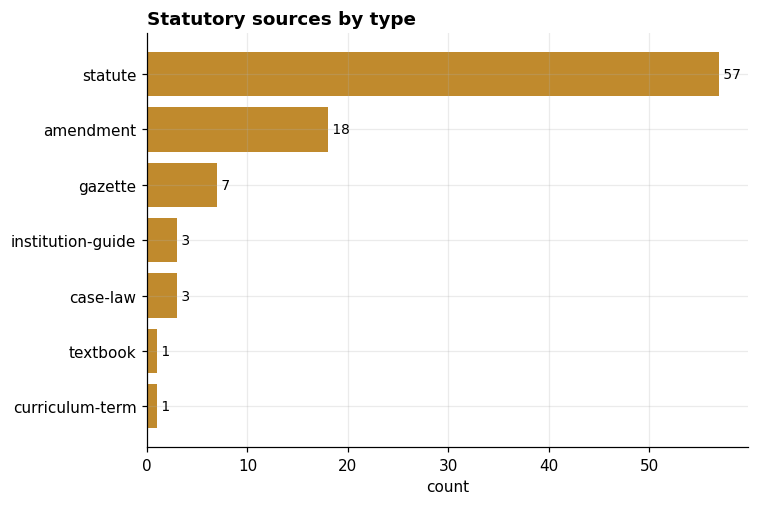

In [4]:
reg = pd.read_csv(MANIFESTS / "source-registry.csv")
print("source-registry.csv:", reg.shape)
by_type = reg["source_type"].value_counts()
print("\nby source_type\n", by_type)
print("\nby status\n", reg["status"].value_counts())

# Coverage across the curriculum topic tree.
topics = pd.read_csv(PROCESSED / "topics.csv")
topic_sources = pd.read_csv(PROCESSED / "topic-sources.csv")
print(f"\ncurriculum topics: {len(topics)} | topic<->source edges: {len(topic_sources)}")

barh(by_type.index.tolist(), by_type.values.tolist(),
     "Statutory sources by type", color=PAL[1])

## 3. Case law: reported vs unreported

The extraction pipeline runs on the **conveyancing-relevant** slice of the case
corpus, recorded in `case_meta.csv`. Each case carries a `reported` flag, and
that flag decides how we get a rule out of it.

**Reported case** — a judgment an editor chose for an official law-report series
(*New Law Reports*, 1878–1978; *Sri Lanka Law Reports*, 1978–). The editor writes
a **headnote**: catchwords plus a `Held:` block that states the legal rule. These
are the CommonLII judgments (courts `LKCA`, `LKSC`). Because the headnote already
*is* the rule, we extract it deterministically — no model.

**Unreported case** — a judgment the Supreme Court / Court of Appeal publish
directly on their own sites (post-2012). No editor, no headnote, often no formal
citation — just the full judgment text (courts `SC`, `COA`). Here a small language
model has to read the reasoning and extract the rule, guarded by a verbatim-quote
check.

case_meta.csv: (5121, 7)

reported vs unreported
 reported
reported      3703
unreported    1418
Name: count, dtype: int64

by court
 court
LKCA    3330
SC       909
COA      509
LKSC     373
Name: count, dtype: int64


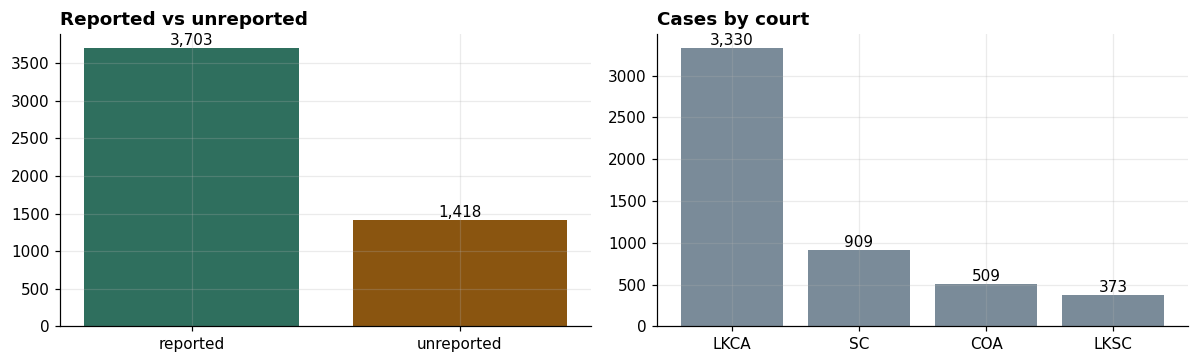

In [5]:
meta = pd.read_csv(OUTPUT / "case_meta.csv")
print("case_meta.csv:", meta.shape)

rep = meta["reported"].map({True: "reported", False: "unreported"}).value_counts()
print("\nreported vs unreported\n", rep)
print("\nby court\n", meta["court"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].bar(rep.index, rep.values, color=[PAL[0], PAL[3]])
axes[0].set_title("Reported vs unreported", loc="left", fontweight="bold")
for i, v in enumerate(rep.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

cc = meta["court"].value_counts()
axes[1].bar(cc.index, cc.values, color=PAL[2])
axes[1].set_title("Cases by court", loc="left", fontweight="bold")
for i, v in enumerate(cc.values):
    axes[1].text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

reported  reported  unreported  total
court                                
LKCA          3330           0   3330
SC               0         909    909
COA              0         509    509
LKSC           373           0    373


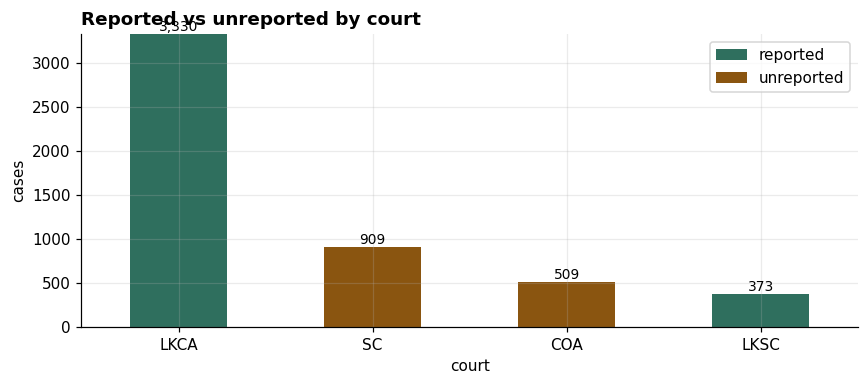

In [6]:
# Reported vs unreported broken down by each court/source.
# reported = CommonLII law-report set (LKCA, LKSC); unreported = official
# court judgments published directly (SC, COA).
ct = pd.crosstab(
    meta["court"],
    meta["reported"].map({True: "reported", False: "unreported"}),
)
for col in ["reported", "unreported"]:
    if col not in ct.columns:
        ct[col] = 0
ct = ct[["reported", "unreported"]]
ct["total"] = ct.sum(axis=1)
ct = ct.sort_values("total", ascending=False)
print(ct)

plot_ct = ct[["reported", "unreported"]]
fig, ax = plt.subplots(figsize=(8, 3.6))
plot_ct.plot(kind="bar", stacked=True, color=[PAL[0], PAL[3]], ax=ax)
ax.set_title("Reported vs unreported by court", loc="left", fontweight="bold")
ax.set_xlabel("court"); ax.set_ylabel("cases")
ax.legend(title="")
for i, (_, row) in enumerate(plot_ct.iterrows()):
    ax.text(i, row.sum(), f"{int(row.sum()):,}", ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()


year range: 1872–2026  |  share pre-1950: 45%


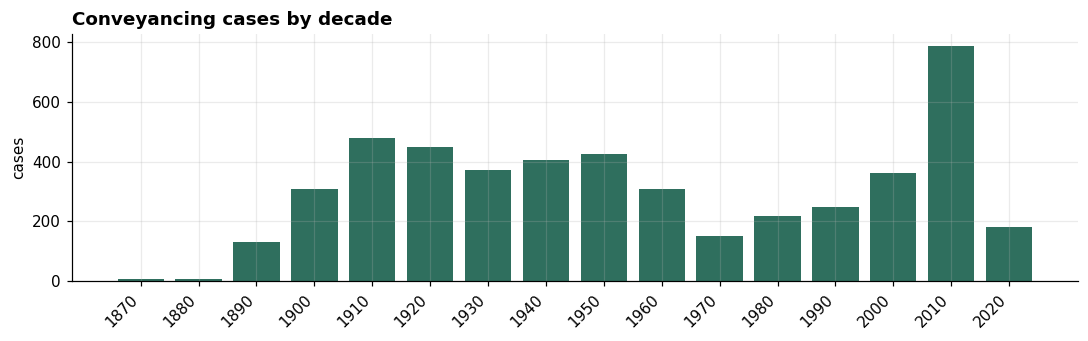

In [7]:
# Time span of the case corpus, by decade. Old judgments dominate.
yr = pd.to_numeric(meta["year"], errors="coerce").dropna().astype(int)
decade = (yr // 10 * 10)
dc = decade.value_counts().sort_index()
pre_1950 = (yr < 1950).mean()
print(f"year range: {yr.min()}–{yr.max()}  |  share pre-1950: {pre_1950:.0%}")

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.bar(dc.index.astype(str), dc.values, color=PAL[0], width=0.8)
ax.set_title("Conveyancing cases by decade", loc="left", fontweight="bold")
ax.set_ylabel("cases")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

## 4. Headnotes — three concrete samples

The deterministic headnote extractor (`headnote.py`, Track A) looks for a `Held:`
marker, then keeps the block up to the next structural marker of the judgment,
and only accepts it when the block is a sensible length (40–2200 chars). The
three cases below show the three outcomes: a clean extraction, a reported case
where the rule fails those checks, and an unreported case with no headnote at
all.

In [8]:
sys.path.insert(0, str(EXTRACT))
from headnote import extract_headnote  # noqa: E402

def read_doc(rel_or_abs):
    p = Path(rel_or_abs)
    if not p.is_absolute():
        p = ROOT / rel_or_abs
    return p.read_text(encoding="utf-8", errors="replace")

def snippet(text, around="Held", before=280, after=520):
    i = text.find(around)
    if i < 0:
        return text[:before + after]
    return text[max(0, i - before): i + after]

SAMPLES = {
    "(a) reported — extractable": "data/processed/docs/case-law/commonlii/LKCA/1905/33.md",
    "(b) reported — NOT cleanly extractable": "data/processed/docs/case-law/commonlii/LKCA/1872/1.md",
    "(c) unreported — no headnote": "data/processed/docs/case-law/courts/coa/06-c-a-phc-176-2014-bc3bb537f6.md",
}

for label, rel in SAMPLES.items():
    text = read_doc(rel)
    result = extract_headnote(text)
    print("=" * 78)
    print(label)
    print("file:", rel, "| chars:", len(text), "| contains 'Held':", "Held" in text)
    print("extract_headnote() ->", "EXTRACTED" if result else "None")
    if result:
        print("catchwords:", result["catchwords"][:160])
        print("held      :", result["held"][:400])
    else:
        print("context   :", " ".join(snippet(text).split())[:520])
    print()

(a) reported — extractable
file: data/processed/docs/case-law/commonlii/LKCA/1905/33.md | chars: 10966 | contains 'Held': True
extract_headnote() -> EXTRACTED
catchwords: 
held      : see Annamalay Pillai v. Perera 2 that a sale in the circumstances in which the substituted plaintiff purchased is absolutely void, and not voidable only, that is to say that the purchaser from a person who has bought at a Fiscal's sale any interest in the land which is the subject of partition derives no title whatever by his purchase. All the previous decisions were reviewed in the case of Annama

(b) reported — NOT cleanly extractable
file: data/processed/docs/case-law/commonlii/LKCA/1872/1.md | chars: 7471 | contains 'Held': True
extract_headnote() -> None
context   : it off, would be a contract ex turpi causa, and a judge would refuse the support of the law to it. 272 Where the donor had said in the deed of gift that she (the donee) is now my concubine," and the woman stated, " He gave it to me becaus

**Reading the output above.**

- **(a)** returns a clean `Held` block and catchwords — the reporter's own words
  become the rule, verbatim, with no model involved.
- **(b)** is a reported case whose `Held` runs straight into the judgment body
  with no clean end marker, so it fails the length/boundary check and returns
  `None`. It falls through to the LLM track.
- **(c)** is an unreported court judgment: no `Held`, no citation, just OCR'd
  prose. Only the LLM track can produce a rule here, and only with a
  verbatim-quote guard.

## 5. Rule extraction results

`rules.csv` holds the extracted rules; `extract-rejects.csv` records every case
that produced no rule and why. The two tracks are `method=headnote` (deterministic,
reported cases) and `method=llm-extract` (bounded model, quote-checked).

rules.csv: (1541, 16) | all status=unverified: True

rules by method
 method
headnote       1065
llm-extract     476
Name: count, dtype: int64

reject reasons
 status
no-headnote               3179
abstained                  608
reject:quote-not-found     333
llm-error                    1
Name: count, dtype: int64

section linking status
 section_status
none                 1321
ok-unchecked           65
section-not-found      59
bad-source             49
ok                     47
Name: count, dtype: int64


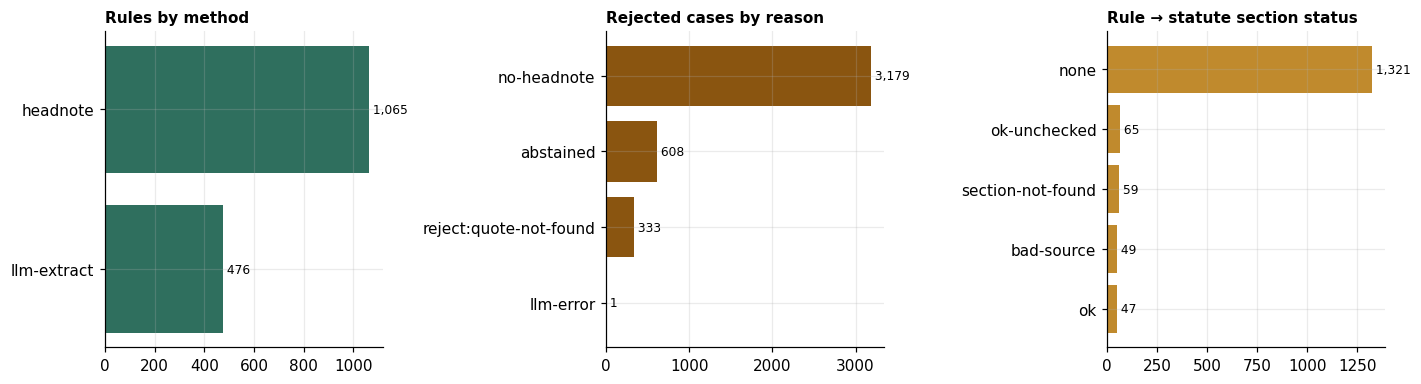

In [9]:
rules = pd.read_csv(OUTPUT / "rules.csv")
rejects = pd.read_csv(OUTPUT / "extract-rejects.csv")
print("rules.csv:", rules.shape, "| all status=unverified:", (rules["status"] == "unverified").all())

by_method = rules["method"].value_counts()
by_reject = rejects["status"].value_counts()
by_section = rules["section_status"].value_counts()
print("\nrules by method\n", by_method)
print("\nreject reasons\n", by_reject)
print("\nsection linking status\n", by_section)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, series, title, color in [
    (axes[0], by_method, "Rules by method", PAL[0]),
    (axes[1], by_reject, "Rejected cases by reason", PAL[3]),
    (axes[2], by_section, "Rule → statute section status", PAL[1]),
]:
    ax.barh(range(len(series)), series.values, color=color)
    ax.set_yticks(range(len(series)))
    ax.set_yticklabels(series.index)
    ax.invert_yaxis()
    ax.set_title(title, loc="left", fontweight="bold", fontsize=10)
    for i, v in enumerate(series.values):
        ax.text(v, i, f" {v:,}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

In [10]:
# Yield: of the cases the pipeline saw, how many produced at least one rule.
n_cases = len(meta)
cases_with_rules = rules["case_id"].nunique()
linked = rules["section_status"].isin(["ok", "ok-unchecked"]).sum()
print(f"cases in extraction set     : {n_cases:,}")
print(f"cases with >=1 rule         : {cases_with_rules:,} ({cases_with_rules / n_cases:.0%})")
print(f"total rules                 : {len(rules):,}")
print(f"  from headnotes            : {by_method.get('headnote', 0):,}")
print(f"  from LLM (quote-checked)  : {by_method.get('llm-extract', 0):,}")
print(f"rules linked to a section   : {linked:,}")
print("\nEvery rule is status=unverified. These counts are yield, not correctness.")

cases in extraction set     : 5,121
cases with >=1 rule         : 1,000 (20%)
total rules                 : 1,541
  from headnotes            : 1,065
  from LLM (quote-checked)  : 476
rules linked to a section   : 112

Every rule is status=unverified. These counts are yield, not correctness.


## 6. Case ↔ statute links and the unresolved queue

Beyond rules, the pipeline builds a citation graph: which case cites which statute
section. `case_statute_section_links.csv` holds the evidence-backed candidate
edges; `unresolved_citations.csv` holds mentions the linker could not pair safely
(mostly bare "section N" with no nearby Act). A 30-edge sample is staged for
lawyer sign-off.

In [11]:
def count_rows(path):
    with open(path, encoding="utf-8", errors="replace") as fh:
        return sum(1 for _ in fh) - 1

n_links = count_rows(PROCESSED / "case_statute_section_links.csv")
n_unresolved = count_rows(PROCESSED / "unresolved_citations.csv")
n_sample = count_rows(PROCESSED / "verification-sample.csv")
print(f"candidate case→section edges : {n_links:,}  (all unverified)")
print(f"unresolved citation mentions : {n_unresolved:,}")
print(f"lawyer verification sample   : {n_sample:,} edges staged for sign-off")

links_head = pd.read_csv(PROCESSED / "case_statute_section_links.csv", nrows=5)
print("\ncase_statute_section_links.csv columns:", list(links_head.columns))
links_head

candidate case→section edges : 14,665  (all unverified)
unresolved citation mentions : 62,385
lawyer verification sample   : 30 edges staged for sign-off

case_statute_section_links.csv columns: ['case_id', 'source_id', 'section', 'confidence', 'confidence_label', 'evidence_snippet', 'case_citation', 'case_title', 'mention_count', 'review_status']


,case_id,source_id,section,confidence,confidence_label,evidence_snippet,case_citation,case_title,mention_count,review_status
0,commonlii-LKCA-1884-2,SRC071,3,1.00,explicit,"r father, ever accepted that gift, it is not o...",37 NLR 201,Fernando Et Al v. Alwis Et Al - NLR - 201 of 3...,1,unverified
1,commonlii-LKCA-1886-2,SRC030,547,1.00,explicit,ndant claimed these lands and one of the mortg...,1 NLR 346,Mohamadu Lebbe v. Umma Natchia - NLR - 346 of ...,1,unverified
2,commonlii-LKCA-1886-2,SRC030,642,1.00,explicit,11 February 1886) 346 MOHAMADU LEBBE v. UMMA N...,1 NLR 346,Mohamadu Lebbe v. Umma Natchia - NLR - 346 of ...,2,unverified
3,commonlii-LKCA-1893-3,SRC001,16,0.55,nearest_unique,"St. V. Jayawardene, K.C. (with him Arulanandan...",23 NLR 417,Suppramaniam Et Al. v. Erampakurukal Et Al. - ...,2,unverified
4,commonlii-LKCA-1893-3,SRC001,2,1.00,explicit,"gistered as they do not transfer any property,...",23 NLR 417,Suppramaniam Et Al. v. Erampakurukal Et Al. - ...,3,unverified


## 8. Reported-case funnel: did we extract every rule?

A reported case *should* be easy — the editor wrote a headnote. But most of
our reported judgments do not carry that headnote in the harvested text, so
Track A only fires on a small fraction. This section quantifies the gap and
shows why a better regex is not the fix.

reported cases total          : 3,703
  with a headnote (Track A) rule: 524 (14%)
  with an LLM   (Track B) rule  : 0 (0%)
  no rule at all (no-headnote)  : 3,179 (86%)


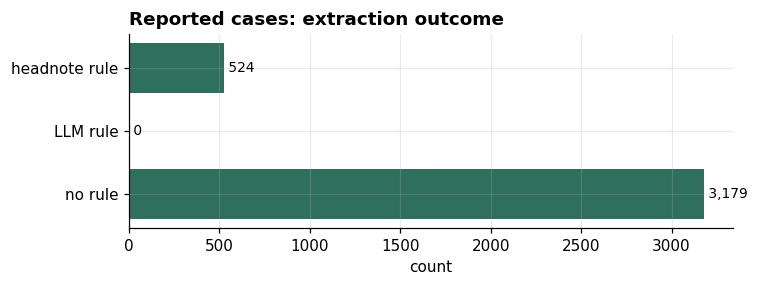

In [12]:
reported_ids = set(meta[meta["reported"] == True]["case_id"])
hn_cases = set(rules[rules["method"] == "headnote"]["case_id"])
llm_cases = set(rules[rules["method"] == "llm-extract"]["case_id"])
no_hn = set(rejects[rejects["status"] == "no-headnote"]["case_id"]) & reported_ids

with_rule = reported_ids & (hn_cases | llm_cases)
n_rep = len(reported_ids)
print(f"reported cases total          : {n_rep:,}")
print(f"  with a headnote (Track A) rule: {len(reported_ids & hn_cases):,} "
      f"({len(reported_ids & hn_cases)/n_rep:.0%})")
print(f"  with an LLM   (Track B) rule  : {len(reported_ids & llm_cases):,} "
      f"({len(reported_ids & llm_cases)/n_rep:.0%})")
print(f"  no rule at all (no-headnote)  : {len(reported_ids - with_rule):,} "
      f"({len(reported_ids - with_rule)/n_rep:.0%})")

funnel = pd.Series({
    "headnote rule": len(reported_ids & hn_cases),
    "LLM rule": len(reported_ids & llm_cases),
    "no rule": len(reported_ids - with_rule),
})
barh(funnel.index.tolist(), funnel.values.tolist(),
     "Reported cases: extraction outcome", color=PAL[0])

### Why a better regex will not recover the rest

Sampling the reported cases that produced no rule and checking what is actually
in the document: is there a clean `Held:` marker the regex missed, only the bare
word "held" in ordinary prose, or no "held" at all?

sampled 800 reported no-rule cases:
  clean 'Held:' marker (regex-recoverable)        5 (1%)
  bare 'held' in prose only (not a headnote)    709 (89%)
  no 'held' at all (headnote absent)             86 (11%)


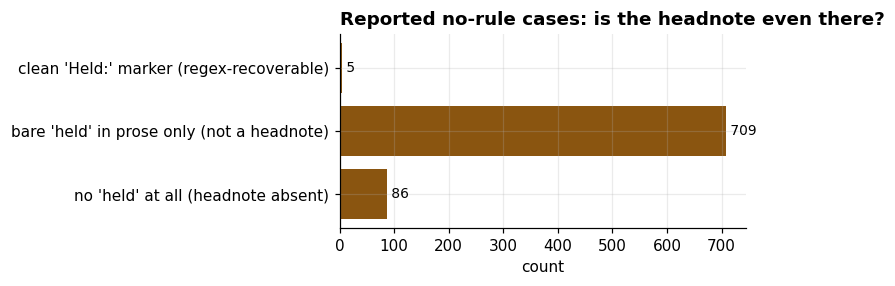

In [13]:
import random, re
from pathlib import Path

text_path = dict(zip(cases["case_id"], cases["text_path"]))
held_marker = re.compile(r"\bHeld\s*[:\-—]", re.I)
held_word = re.compile(r"\bHeld\b", re.I)

random.seed(0)
sample = random.sample(sorted(no_hn), min(800, len(no_hn)))
buckets = {"clean 'Held:' marker (regex-recoverable)": 0,
           "bare 'held' in prose only (not a headnote)": 0,
           "no 'held' at all (headnote absent)": 0}
n = 0
for cid in sample:
    rel = text_path.get(cid)
    fp = ROOT / rel if rel and not Path(rel).is_absolute() else Path(rel or "")
    if not fp.exists():
        continue
    t = fp.read_text(encoding="utf-8", errors="replace")
    n += 1
    if held_marker.search(t):
        buckets["clean 'Held:' marker (regex-recoverable)"] += 1
    elif held_word.search(t):
        buckets["bare 'held' in prose only (not a headnote)"] += 1
    else:
        buckets["no 'held' at all (headnote absent)"] += 1

print(f"sampled {n} reported no-rule cases:")
for k, v in buckets.items():
    print(f"  {k:44s} {v:4d} ({v/n:.0%})")
barh(list(buckets.keys()), list(buckets.values()),
     "Reported no-rule cases: is the headnote even there?", color=PAL[3])

**Conclusion.** Only ~1% of the no-rule reported cases hold a clean `Held:`
block the current regex missed, so a better regex recovers almost nothing.
~89% contain "held" only as an ordinary word in the judgment ("the judge held
that...") — matching those would fabricate rules from prose. The editor's
headnote simply is not in the harvested text for these cases.

**What we do and do not hold for recovery.**

- **LawNet** (`lawnet.gov.lk`, official/free): not acquired — the site was dead
  during harvesting. We have nothing from it.
- **LawLanka** (commercial): index only — `slr-modern-cases.csv` is 630 modern
  SLR titles/citations/URLs (2012–2021), `status=indexed_reference`, full text
  paywalled and copyright. No judgment text, no headnotes.

So headnotes for the ~3,179 reported cases are not sitting in our data. The two
real levers are (1) run the quote-checked LLM track (Track B) on the CommonLII
judgment bodies we already hold — more coverage, lower precision (~58% usable
in the ablation) — or (2) acquire the real headnotes via the official LawNet /
university data request. Either way, lawyer verification stays the gate.

## 7. Takeaways

- The corpus is large and mostly acquired: ~9,300 normalized documents, ~9,200
  case records, 90 statutory sources, a 14,665-edge case→section graph.
- Case law splits cleanly into **reported** (headnote → deterministic rule) and
  **unreported** (no headnote → quote-checked LLM rule).
- The corpus skews old (large pre-1950 share), and many old judgments construe
  repealed statutes — the main reason to consider dropping or down-weighting
  them, and a driver of statute-attribution errors in extraction.
- **Nothing here is verified.** Every extracted rule and every case→section link
  is `status=unverified`. The counts above are coverage and yield, not
  legal-correctness scores; lawyer review is the required gate before any of it
  is treated as authority.